In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
# # for google colab

# !pip install pypose
# !pip install kornia

In [15]:
# from google.colab import drive
# drive.mount('/content/drive')
# !unzip -q /content/drive/MyDrive/SonarOdometryDataset/SonarOdometryDataset_sample.zip -d /content/drive/MyDrive/SonarOdometryDataset/SonarOdometryDataset_sample

In [16]:
# %cd /content/
# !git clone https://github.com/MarcinJanis/SonarOdometry.git
# %cd SonarOdometry


In [17]:
import os
import sys

import cv2

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from box import Box
import yaml

import matplotlib.pyplot as plt

from scipy.spatial.transform import Rotation as R
import random

import time

from tqdm import tqdm

import pywt
from sklearn.decomposition import MiniBatchDictionaryLearning
from sklearn.feature_extraction.image import extract_patches_2d, reconstruct_from_patches_2d
import warnings


root_dir = os.path.abspath('../..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.data_loader.evaluation_data_generator import DataGenerator
from src.models.patchifier import Patchifier

from src.data_loader.metrics import eval_metrics_2d
# from training.utils import pose_err


In [18]:
root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry'
# root_dir = '/content/SonarOdometry'

model_config_pth = os.path.join(root_dir, 'config/model2d.yaml')
sonar_config_pth = os.path.join(root_dir, 'config/sonar.yaml')

data_root_dir = os.path.join(root_dir, 'data/aracati2017')

# data_root_dir = '/content/drive/MyDrive/SonarOdometryDataset/SonarOdometryDataset_sample/SonarOdometryDataset_sample/seq_15'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(model_config_pth, "r") as f:
            model_config = Box(yaml.safe_load(f))

with open(sonar_config_pth, "r") as f:
            sonar_config = Box(yaml.safe_load(f))

from src.models.utils import ExtrinsicsCalib
extrinsics_calib = ExtrinsicsCalib(T = [sonar_config.position.x, sonar_config.position.y, sonar_config.position.z],
                                   R = [sonar_config.position.roll, sonar_config.position.pitch, sonar_config.position.yaw])


from src.data_loader.transforms import SonarDatasetTranforms


fls_resolution = (model_config.FLS_INPUT_HEIGHT, model_config.FLS_INPUT_WIDTH) # for own ds
fls_resolution = (model_config.ARACATI_FLS_INPUT_HEIGHT, model_config.ARACATI_FLS_INPUT_WIDTH) # for aracati 

data_generator = DataGenerator(data_root_dir, device, fls_resolution=fls_resolution, transforms = None, calibration = extrinsics_calib)
data_lenght = data_generator.get_len()
print(f'Data generator initialized.')
print(f'Data series lenght: {data_lenght}')


from src.models.odometry2d import sonar_odometry



Data generator initialized.
Data series lenght: 14436


In [19]:
def fls_filter(frame):

    # convert troch tensor to numpy array
    device = frame.device 

    _, _, c, h, w = frame.shape
    frame_reshaped = frame.view(h, w, 1)

    frame_np = frame_reshaped.detach().cpu().numpy()
    frame_np = (frame_np * 255).astype(np.uint8)

    # median filter 
    print(f'shape: {frame_np.shape}')
    blured = cv2.medianBlur(frame_np, ksize=5)

    # CLAHE 
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    filtered_frame = clahe.apply(blured)

    # restore tensor form 
    frame_torch = torch.tensor(blured / 255, dtype = torch.float, device = device)
    frame_reshaped = frame_torch.view(1, 1, 1, h, w)
    # frame_reshaped.to(device)

    return frame_reshaped


def display_format(frame):

    _, _, c, h, w = frame.shape

    # corect dimensions
    frame_reshaped = frame.view(h, w, 1)

    # convert to numpy 
    frame_np = frame_reshaped.detach().cpu().numpy()

    # corect values and dtype
    frame_disp = (frame_np * 255).astype(np.uint8)

    return frame_disp


def normalize_sonar_frame(frame_tensor):
    # Zamiast CLAHE/Blur, zastosuj statystyczną normalizację:
    # 1. Obetnij wartości odstające (np. 2% najjaśniejszych i najciemniejszych)
    # 2. Przeskaluj do [0, 1]
    
    # Opcja 1: Standardowa (Zero Mean, Unit Variance)
    mean = frame_tensor.mean()
    std = frame_tensor.std()
    return (frame_tensor - mean) / (std + 1e-6)

torch.Size([1, 1, 1, 424, 776])
shape: (424, 776, 1)


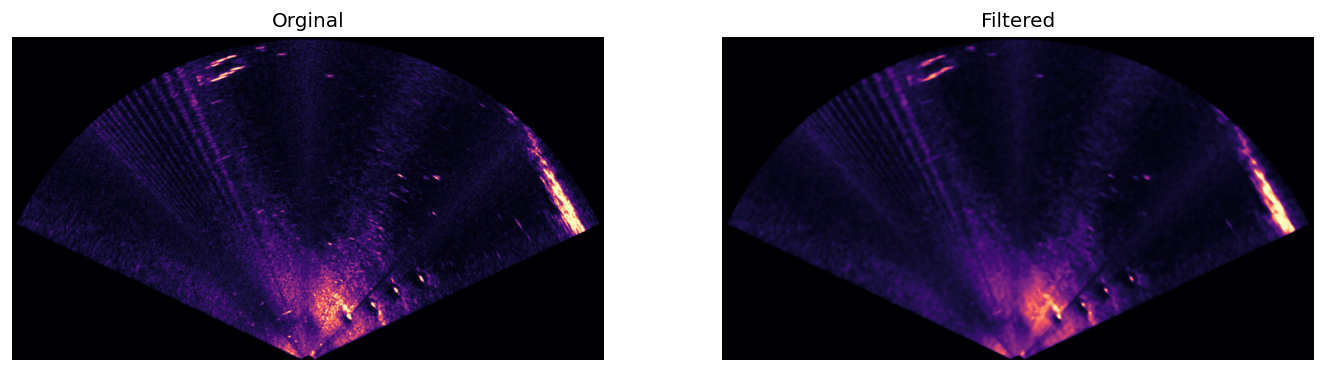

In [20]:
# get sample
idx = 200
t, frame, pose_gt, depth = data_generator.get_sample(idx, return_visu=False, return_depth=True)
print(frame.shape)

# filter 
frame_filtered = fls_filter(frame)

# convert do display format 
frame_org_np = display_format(frame)
frame_filtered_np = display_format(frame_filtered)

fig, ax = plt.subplots(1, 2, figsize=(14, 7), dpi=120)

ax[0].imshow(frame_org_np, cmap = 'magma')
ax[0].set_title(f'Orginal')

ax[1].imshow(frame_filtered_np, cmap = 'magma')
ax[1].set_title(f'Filtered')



ax[0].axis('off')
ax[1].axis('off')
plt.show()


In [21]:
def visualize_loftr_matches(visu, num_matches=100):

    img = visu['combined_imgs']
    pts1 = visu['pts1']
    pts2 = visu['pts2']
    offset_x = visu['pts2_offset'][1]

    if len(pts1) == 0:
        print("Brak dopasowań do wyświetlenia!")
        return

    n = min(len(pts1), num_matches)
    indices = np.random.choice(len(pts1), n, replace=False)

    fig, ax = plt.subplots(figsize=(14, 7), dpi=120)
    ax.imshow(img)

    for i in indices:
        x1, y1 = pts1[i]
        x2, y2 = pts2[i]

        ax.plot([x1, x2 + offset_x], [y1, y2], color='cyan', linewidth=0.8, alpha=0.5)
        ax.plot(x1, y1, 'ro', markersize=3)
        ax.plot(x2 + offset_x, y2, 'go', markersize=3)

    ax.set_title(f'Matched points ({n}/{len(pts1)} points displayed)')
    ax.axis('off')
    plt.show()

(424, 776)
torch.Size([1, 424, 776])


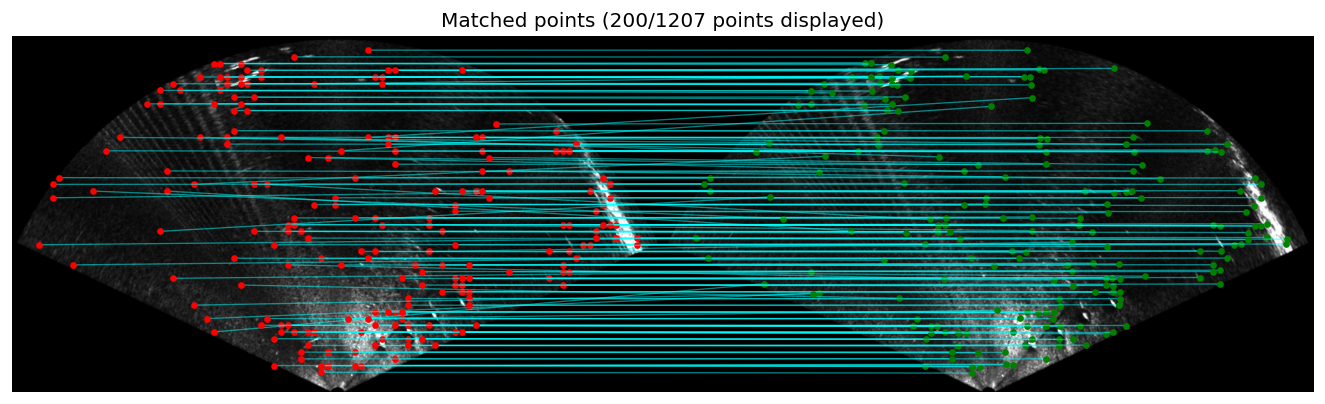

Inliers: 0.3968516984258492/1207


In [ ]:
from src.models.odometry2d import sonar_odometry

model = sonar_odometry(model_config, sonar_config, device = device,
                       depth_compesation = True,
                       key_frames = True,
                       input_img_format = 'cart')

idx1 = 400
idx2 = 404

t1, frame1, pose_g1, depth1 = data_generator.get_sample(idx1, return_visu=False, return_depth=True)
t2, frame2, pose_g2, depth2 = data_generator.get_sample(idx2, return_visu=False, return_depth=True)

mask_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/data/aracati2017/mask_424x776.png'
mask_np = cv2.imread(mask_pth, 0)
print(mask_np.shape)
mask_torch = torch.tensor(mask_np, dtype=torch.float, device=device)
mask_torch = mask_torch.squeeze(-1).unsqueeze(0)
print(mask_torch.shape)

model.set_init_state(0.0, 0.0, 0.0, frame1.squeeze(1), mask_torch)


pred_pose, pred_azimuth, visu = model(frame2.squeeze(1).to(device), depth2.to(device), return_visu = True)

visualize_loftr_matches(visu, num_matches=200)

print(f"Inliers: {visu['inlier_num']}/{visu['pts1'].shape[0]}")

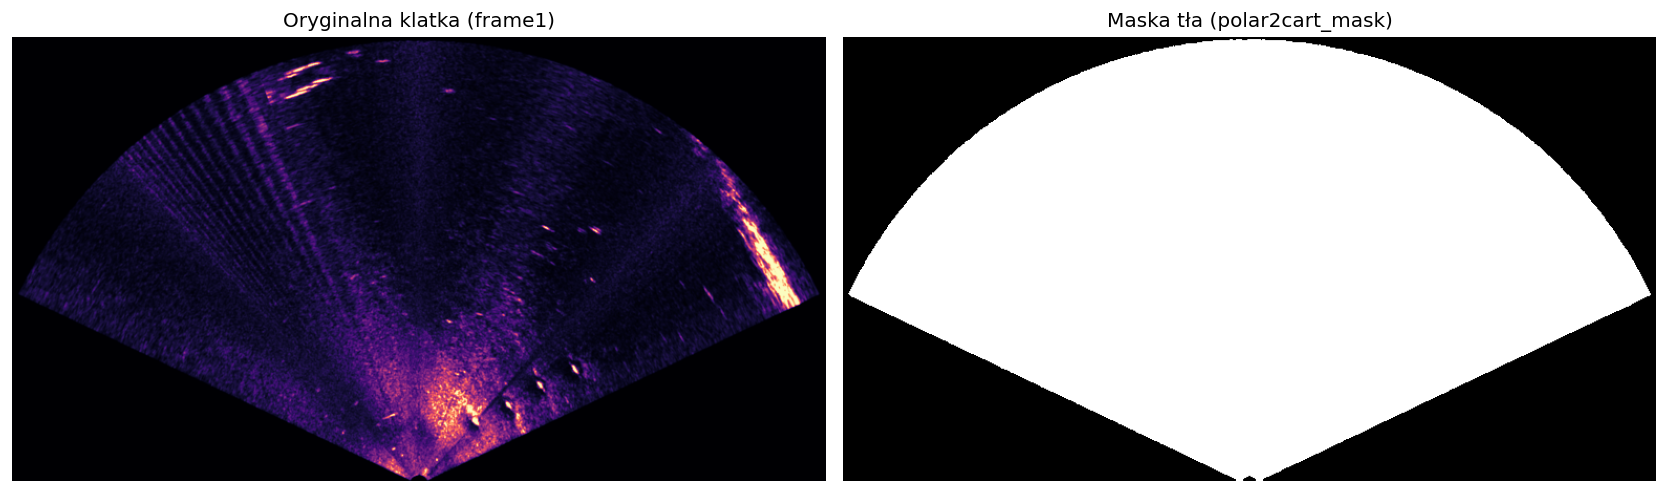

True

In [ ]:
# mask_real = ((mask_np == 0)*255).astype(np.uint8)
# # 3. Wyświetlanie obok siebie
# fig, ax = plt.subplots(1, 2, figsize=(14, 7), dpi=120)

# # Oryginał
# ax[0].imshow(img_org, cmap="magma")
# ax[0].set_title("Oryginalna klatka (frame1)")
# ax[0].axis("off")

# # Maska
# # Używamy cmap='gray', gdzie True (tło) będzie białe, a False (sonar) czarne
# # Możesz też użyć cmap='jet' lub innego, jeśli wolisz żywsze kolory
# ax[1].imshow(mask_real, cmap="gray")
# ax[1].set_title("Maska tła (polar2cart_mask)")
# ax[1].axis("off")

# plt.tight_layout()
# plt.show()

# cv2.imwrite('C:/Users/janis/Projekty/Magisterka/SonarOdometry/data/aracati2017/mask_424x776.png', mask_real)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.77582..10.394652].


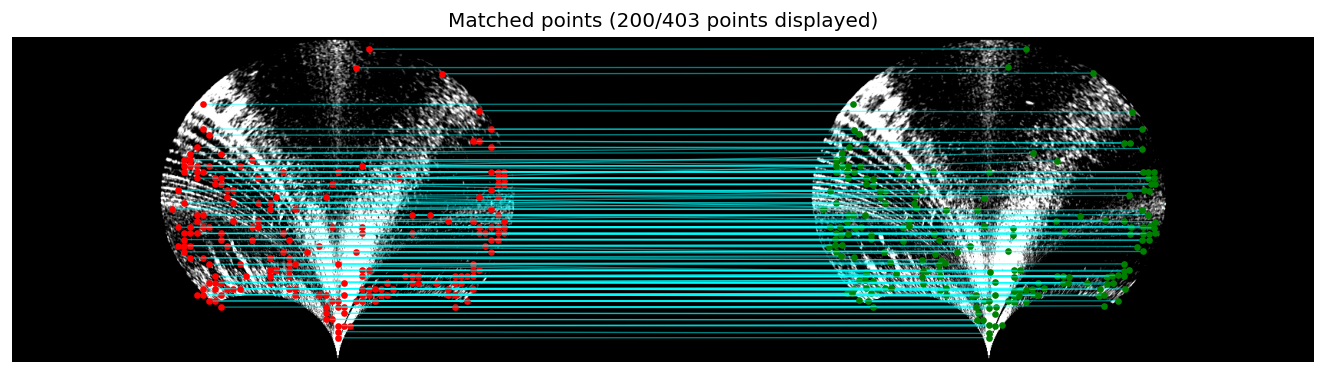

Inliers: 0.48635235732009924/403


In [24]:
model = sonar_odometry(model_config, sonar_config, device = device,
                       depth_compesation = True,
                       key_frames = True)

idx1 = 0
idx2 = 1

t1, frame1, pose_g1, depth1 = data_generator.get_sample(idx1, return_visu=False, return_depth=True)
t2, frame2, pose_g2, depth2 = data_generator.get_sample(idx2, return_visu=False, return_depth=True)

frame1_filtered = normalize_sonar_frame(frame1)
model.set_init_state(0.0, 0.0, 0.0, frame1_filtered.squeeze(1))

frame2_filtered = normalize_sonar_frame(frame2)
pred_pose, pred_azimuth, visu = model(frame2_filtered.squeeze(1).to(device), depth.to(device), return_visu = True)

visualize_loftr_matches(visu, num_matches=200)

print(f"Inliers: {visu['inlier_num']}/{visu['pts1'].shape[0]}")

Wnioski: 

- Filtracja (median, median + CLAHE) zmniejszały liczbę inlierów (procent)
- Normalizacja zostawiałą powodbny provent inlierów ale liczba wykrywtych punktów spadała kilkukrotnie.